# PR-10: Real-Data Ingestion + Pseudo-Labels

Load `load_gift_subset` output and inspect:
1. Sample windows from each dataset
2. Pseudo-label distributions per dataset
3. Inter-label correlation matrix
4. Label variance partitioning: how much variance is explained by `dataset_id`?

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), ''))
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd())))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

# Add mech_interp to path so 'lib' is importable
MECH_INTERP = Path(os.getcwd()).parent
sys.path.insert(0, str(MECH_INTERP))

from lib.real_data import load_gift_subset, GIFT_DATASETS

print('Loading gift subset (n_per_dataset=100 for speed)...')
ds = load_gift_subset(n_per_dataset=100)
print({k: (v.shape, v.dtype) for k, v in ds.items()})

Loading gift subset (n_per_dataset=100 for speed)...
{'series': ((900, 576), dtype('float32')), 'dataset_id': ((900,), dtype('int32')), 'stl_trend_strength': ((900,), dtype('float32')), 'stl_seasonal_strength': ((900,), dtype('float32')), 'fft_dominant_period': ((900,), dtype('float32')), 'fft_top1_power_frac': ((900,), dtype('float32')), 'spectral_flatness': ((900,), dtype('float32')), 'adf_pvalue': ((900,), dtype('float32')), 'hurst_exponent': ((900,), dtype('float32')), 'sample_entropy': ((900,), dtype('float32')), 'n_changepoints': ((900,), dtype('float32')), 'context_std': ((900,), dtype('float32')), 'context_acf_lag1': ((900,), dtype('float32'))}


In [2]:
PSEUDO_LABELS = [
    'stl_trend_strength', 'stl_seasonal_strength',
    'fft_dominant_period', 'fft_top1_power_frac',
    'spectral_flatness', 'adf_pvalue',
    'hurst_exponent', 'sample_entropy',
    'n_changepoints', 'context_std', 'context_acf_lag1',
]

DATASET_SHORT = [
    'elec/H', 'solar/H', 'kdd/H', 'loop/H',
    'm4_d', 'm4_h', 'ett1/H', 'temp_rain', 'jena',
]

N_DATASETS = len(GIFT_DATASETS)
N = ds['series'].shape[0]
n_per = N // N_DATASETS
print(f'Total windows: {N}, per dataset: {n_per}')

Total windows: 900, per dataset: 100


## 1. Sample windows from each dataset

One representative window per dataset (first window), raw series.

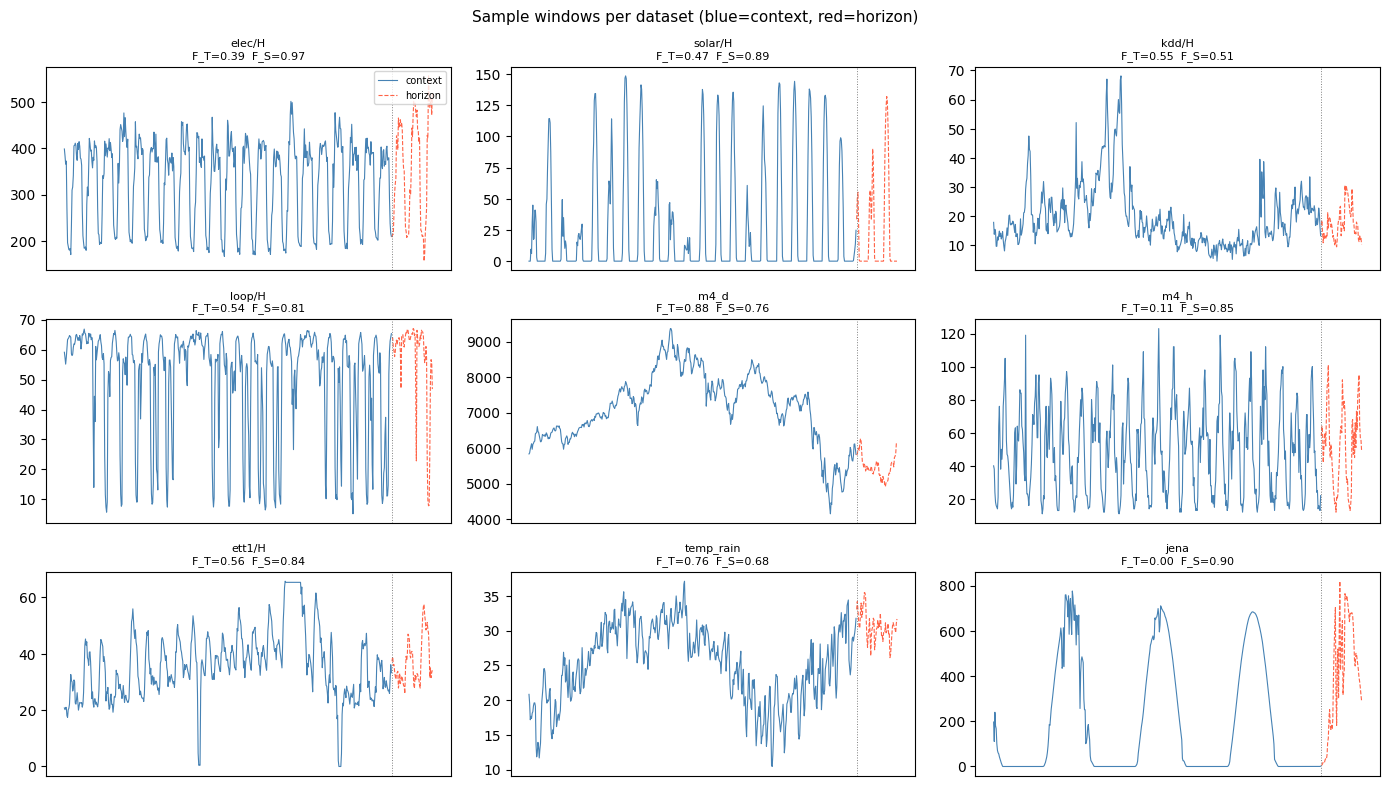

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(14, 8), sharey=False)
axes = axes.flatten()

for i in range(N_DATASETS):
    ax = axes[i]
    idx = i * n_per  # first window from each dataset
    series = ds['series'][idx]
    ctx_len = 512
    ax.plot(range(ctx_len), series[:ctx_len], color='steelblue', lw=0.8, label='context')
    ax.plot(range(ctx_len, len(series)), series[ctx_len:], color='tomato', lw=0.8, ls='--', label='horizon')
    ax.axvline(ctx_len, color='gray', lw=0.7, ls=':')

    # annotate with a couple of pseudo-label values
    ft = ds['stl_trend_strength'][idx]
    fs = ds['stl_seasonal_strength'][idx]
    ax.set_title(f'{DATASET_SHORT[i]}\nF_T={ft:.2f}  F_S={fs:.2f}', fontsize=8)
    ax.set_xticks([])
    # ax.set_yticks([])

axes[0].legend(fontsize=7, loc='upper right')
fig.suptitle('Sample windows per dataset (blue=context, red=horizon)', fontsize=11)
plt.tight_layout()
plt.savefig('figures/pr10_sample_windows.pdf', bbox_inches='tight')
plt.show()

## 2. Pseudo-label distributions per dataset

Box plots for each pseudo-label, one box per dataset.

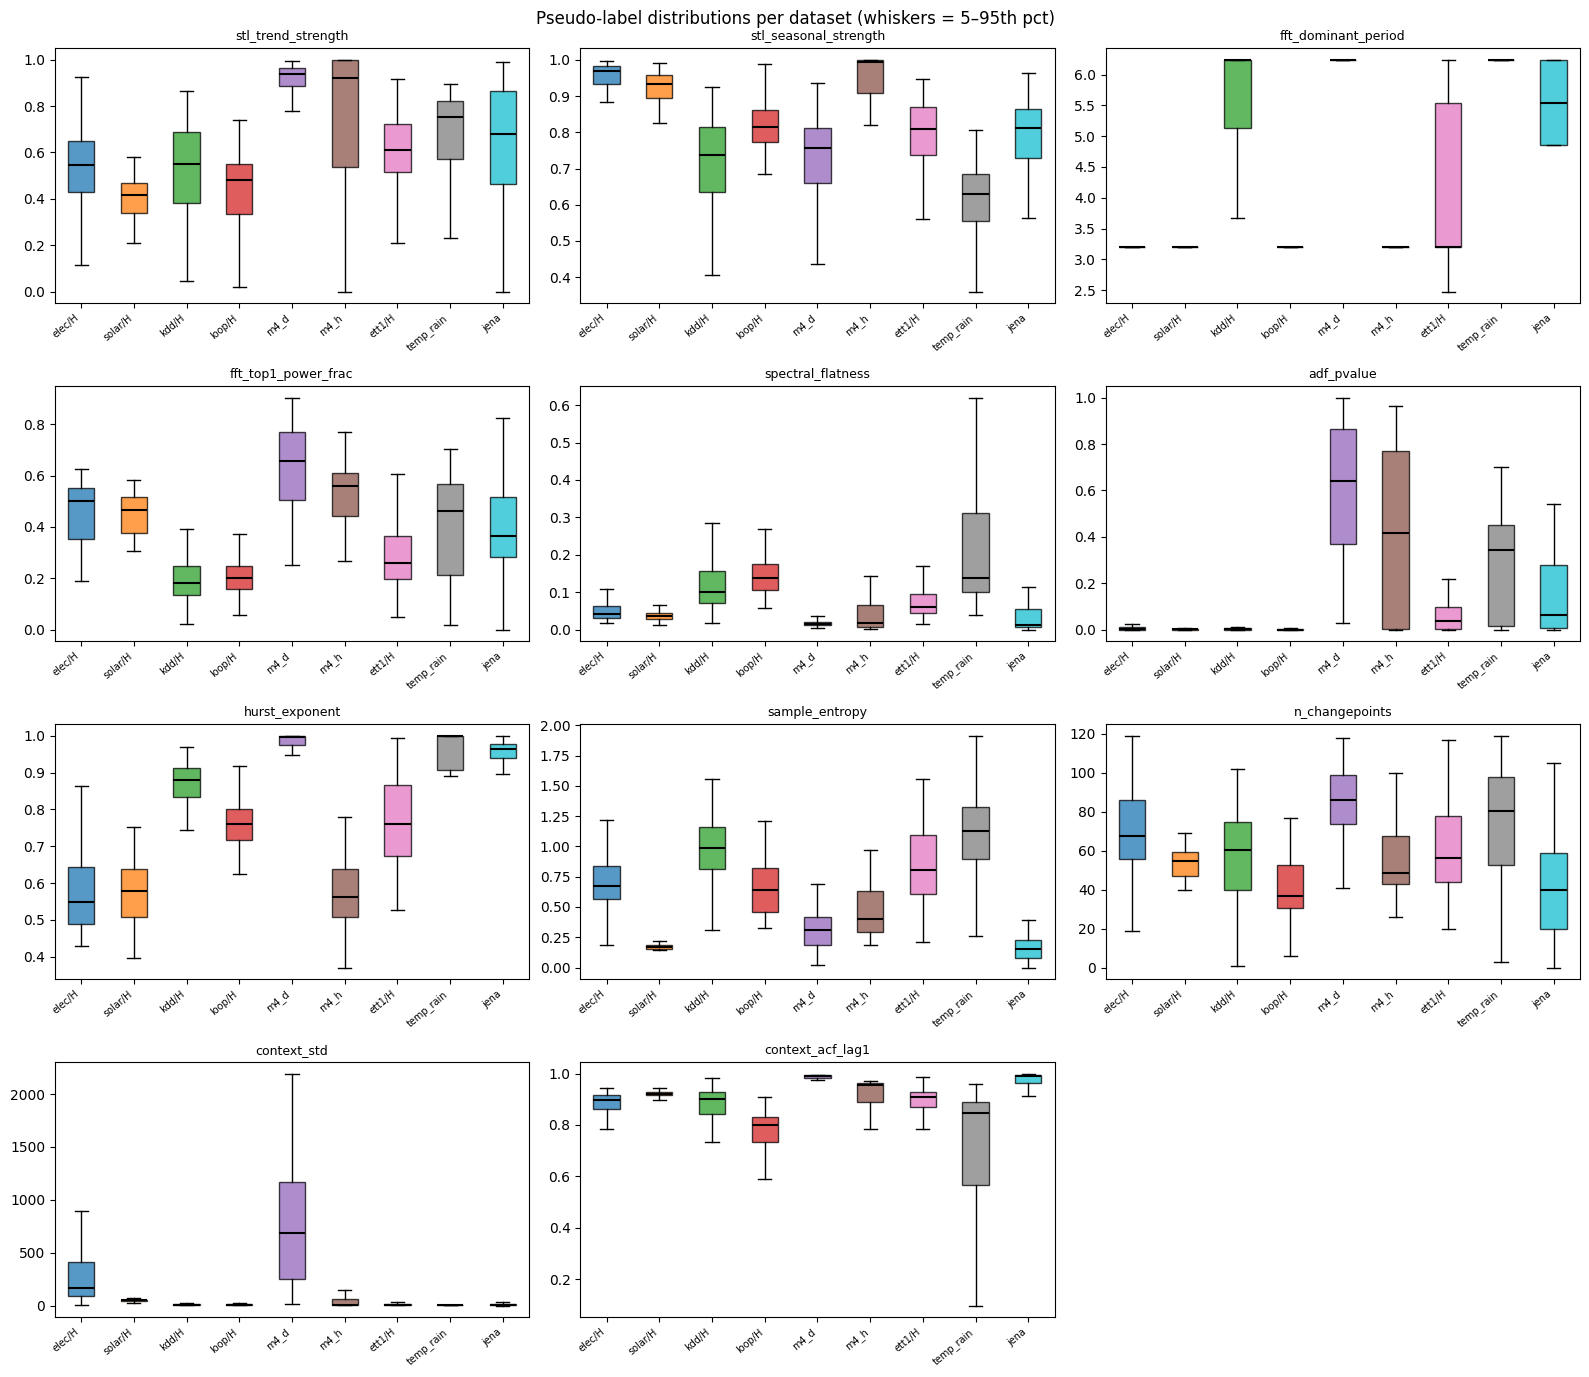

In [4]:
n_cols = 3
n_rows = (len(PSEUDO_LABELS) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.5 * n_rows))
axes = axes.flatten()

for ax_i, label in enumerate(PSEUDO_LABELS):
    ax = axes[ax_i]
    vals = ds[label].astype(np.float64)
    groups = []
    for did in range(N_DATASETS):
        mask = ds['dataset_id'] == did
        g = vals[mask]
        g = g[np.isfinite(g)]
        groups.append(g)

    bp = ax.boxplot(groups, patch_artist=True, showfliers=False,
                    medianprops=dict(color='black', lw=1.5))
    colors = plt.cm.tab10(np.linspace(0, 0.9, N_DATASETS))
    for patch, c in zip(bp['boxes'], colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.75)

    ax.set_xticks(range(1, N_DATASETS + 1))
    ax.set_xticklabels(DATASET_SHORT, rotation=40, ha='right', fontsize=7)
    ax.set_title(label, fontsize=9)
    ax.set_ylabel('')

for ax in axes[len(PSEUDO_LABELS):]:
    ax.set_visible(False)

fig.suptitle('Pseudo-label distributions per dataset (whiskers = 5–95th pct)', fontsize=12)
plt.tight_layout()
plt.savefig('figures/pr10_label_distributions.pdf', bbox_inches='tight')
plt.show()

## 3. Inter-label correlation matrix

Pearson correlations across all 5400 windows. Reveals which pseudo-labels carry redundant information.

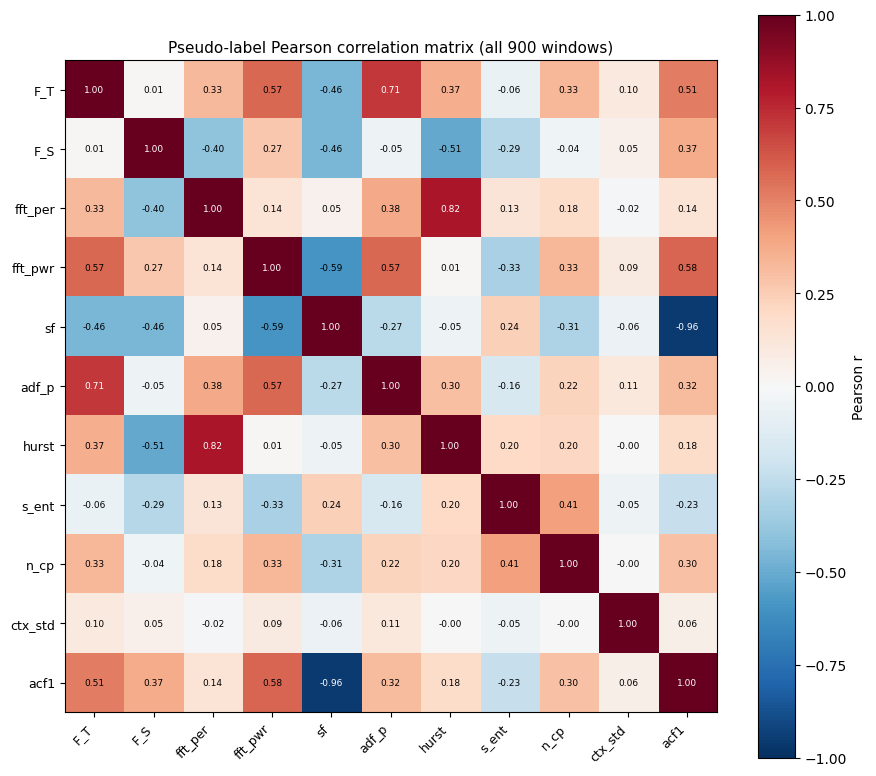

In [5]:
# Build matrix, masking NaNs per pair
X = np.stack([ds[l].astype(np.float64) for l in PSEUDO_LABELS], axis=1)  # [N, 11]

K = len(PSEUDO_LABELS)
corr = np.full((K, K), np.nan)
for i in range(K):
    for j in range(K):
        valid = np.isfinite(X[:, i]) & np.isfinite(X[:, j])
        if valid.sum() > 10:
            c = np.corrcoef(X[valid, i], X[valid, j])[0, 1]
            corr[i, j] = c

short_labels = [
    'F_T', 'F_S', 'fft_per', 'fft_pwr',
    'sf', 'adf_p', 'hurst', 's_ent',
    'n_cp', 'ctx_std', 'acf1',
]

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label='Pearson r')
ax.set_xticks(range(K))
ax.set_yticks(range(K))
ax.set_xticklabels(short_labels, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(short_labels, fontsize=9)

for i in range(K):
    for j in range(K):
        if not np.isnan(corr[i, j]):
            ax.text(j, i, f'{corr[i,j]:.2f}', ha='center', va='center',
                    fontsize=6.5, color='white' if abs(corr[i,j]) > 0.6 else 'black')

ax.set_title('Pseudo-label Pearson correlation matrix (all 900 windows)', fontsize=11)
plt.tight_layout()
plt.savefig('figures/pr10_label_correlation.pdf', bbox_inches='tight')
plt.show()

## 4. Dataset-ID variance explained per pseudo-label

For each label, fit a one-way ANOVA: R² = between-group SS / total SS.  
High R² means the label mainly tracks *which dataset* a window came from, not
window-level structure — useful for identifying potential probe confounds.

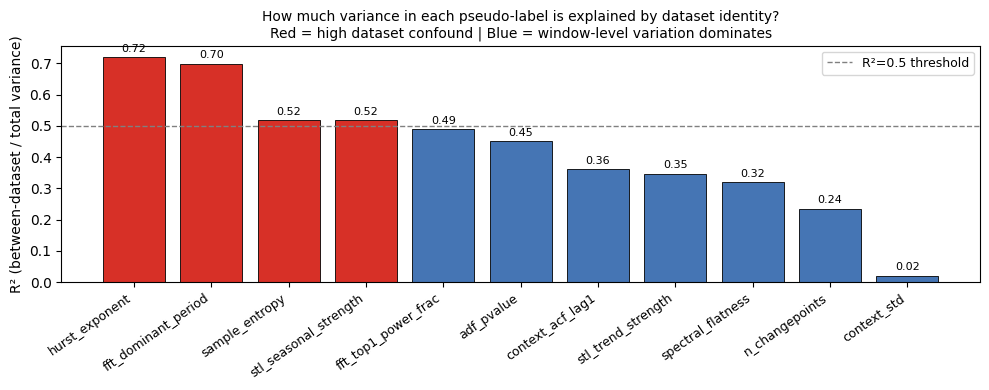

In [10]:
r2_by_dataset = {}
for label in PSEUDO_LABELS:
    vals = ds[label].astype(np.float64)
    valid = np.isfinite(vals)
    y = vals[valid]
    dids = ds['dataset_id'][valid]
    grand_mean = y.mean()
    ss_total = ((y - grand_mean) ** 2).sum()
    if ss_total < 1e-10:
        r2_by_dataset[label] = np.nan
        continue
    ss_between = sum(
        len(y[dids == d]) * (y[dids == d].mean() - grand_mean) ** 2
        for d in range(N_DATASETS)
        if (dids == d).sum() > 0
    )

    r2_by_dataset[label] = ss_between / ss_total

labels_sorted = sorted(r2_by_dataset, key=lambda k: r2_by_dataset[k] or 0, reverse=True)
r2_vals = [r2_by_dataset[l] for l in labels_sorted]

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#d73027' if r > 0.5 else '#4575b4' for r in r2_vals]
bars = ax.bar(range(len(labels_sorted)), r2_vals, color=colors, edgecolor='black', lw=0.6)
ax.axhline(0.5, color='gray', lw=1, ls='--', label='R²=0.5 threshold')
ax.set_xticks(range(len(labels_sorted)))
ax.set_xticklabels(labels_sorted, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('R² (between-dataset / total variance)', fontsize=10)
ax.set_title('How much variance in each pseudo-label is explained by dataset identity?\n'
             'Red = high dataset confound | Blue = window-level variation dominates', fontsize=10)
ax.legend(fontsize=9)
for bar, r in zip(bars, r2_vals):
    if r is not None and not np.isnan(r):
        ax.text(bar.get_x() + bar.get_width()/2, r + 0.01, f'{r:.2f}',
                ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('figures/pr10_dataset_variance.pdf', bbox_inches='tight')
plt.show()

## 5. Label value summary table

In [11]:
print(f"{'Label':<28} {'mean':>8} {'std':>8} {'nan%':>7} {'dataset R²':>11}")
print('-' * 65)
for label in PSEUDO_LABELS:
    v = ds[label].astype(np.float64)
    nan_pct = 100 * np.isnan(v).mean()
    r2 = r2_by_dataset.get(label, float('nan'))
    r2_str = f'{r2:.3f}' if r2 is not None and not np.isnan(r2) else '  nan'
    finite = v[np.isfinite(v)]
    print(f'{label:<28} {finite.mean():>8.3f} {finite.std():>8.3f} {nan_pct:>6.1f}% {r2_str:>11}')

Label                            mean      std    nan%  dataset R²
-----------------------------------------------------------------
stl_trend_strength              0.602    0.255    0.2%       0.347
stl_seasonal_strength           0.804    0.154    0.2%       0.518
fft_dominant_period             4.496    1.426    0.0%       0.699
fft_top1_power_frac             0.393    0.195    0.0%       0.488
spectral_flatness               0.089    0.119    0.0%       0.320
adf_pvalue                      0.188    0.289    0.2%       0.452
hurst_exponent                  0.774    0.182    0.0%       0.721
sample_entropy                  0.612    0.415    0.0%       0.518
n_changepoints                 59.413   25.768    0.0%       0.235
context_std                   289.444 2884.379    0.0%       0.021
context_acf_lag1                0.878    0.143    0.2%       0.361
